# Implementació models baseline

In [2]:
import pandas as pd
import numpy as np

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Preprocesat
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Mètriques
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay

# Gràfiques
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
import numpy as np

# Importar el dataset net
df = pd.read_csv("insurance_claims_clean.csv")

#print(df.head())
#print(df.shape)
#print(df.info())

In [4]:
df.head()

,months_as_customer,age,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_binary
0,328,48,2014-10-17,OH,250/500,1000,1406.91,0,466132,MALE,...,2,YES,71610,6510,13020,52080,Saab,92x,2004,1
1,228,42,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,MALE,...,0,?,5070,780,780,3510,Mercedes,E400,2007,1
2,134,29,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,FEMALE,...,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,0
3,256,41,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,FEMALE,...,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,1
4,228,44,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,MALE,...,1,NO,6500,1300,650,4550,Accura,RSX,2009,0


## 1. Preparació de les dades i selecció inicial de features

In [6]:
# 1. Convertir dates a datetime
df["policy_bind_date"] = pd.to_datetime(df["policy_bind_date"])
df["incident_date"] = pd.to_datetime(df["incident_date"])

# 2. Crear noves variables temporals
df["policy_year"] = df["policy_bind_date"].dt.year
df["policy_month"] = df["policy_bind_date"].dt.month
df["incident_year"] = df["incident_date"].dt.year
df["incident_month"] = df["incident_date"].dt.month
df["client_tenure"] = df["months_as_customer"]  # ja tens antiguitat en mesos

# 3. Selecció inicial de features
# Eliminem les columnes que ja no necessitem
cols_to_drop = ["policy_bind_date", "incident_date", "total_claim_amount", 
                "injury_claim", "property_claim", "vehicle_claim", "insured_zip"]
df_model = df.drop(columns=cols_to_drop)

# 4. Separar target i features
y = df_model["fraud_binary"]
X = df_model.drop(columns=["fraud_binary"])

# 5. Identificar variables categòriques i numèriques
categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

print("Variables categòriques:", categorical_cols)
print("Variables numèriques:", numerical_cols)

Variables categòriques: ['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'property_damage', 'police_report_available', 'auto_make', 'auto_model']
Variables numèriques: ['months_as_customer', 'age', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'auto_year', 'policy_year', 'policy_month', 'incident_year', 'incident_month', 'client_tenure']


Les variables categòriques s'hauran de transformar abans d'entrar-les a un model (one-hot encoding (pd.get_dummies) o label encoding segons el model). De les variables numèriques, algunes variables ja estan relacionades amb temps (policy_year, policy_month, incident_year, incident_month, client_tenure) i poden ajudar el model a capturar patrons temporals.
Altres com months_as_customer i client_tenure representen antiguitat del client (poden ser molt rellevants).

In [8]:
df_model.head()

,months_as_customer,age,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,insured_occupation,...,police_report_available,auto_make,auto_model,auto_year,fraud_binary,policy_year,policy_month,incident_year,incident_month,client_tenure
0,328,48,OH,250/500,1000,1406.91,0,MALE,MD,craft-repair,...,YES,Saab,92x,2004,1,2014,10,2015,1,328
1,228,42,IN,250/500,2000,1197.22,5000000,MALE,MD,machine-op-inspct,...,?,Mercedes,E400,2007,1,2006,6,2015,1,228
2,134,29,OH,100/300,2000,1413.14,5000000,FEMALE,PhD,sales,...,NO,Dodge,RAM,2007,0,2000,9,2015,2,134
3,256,41,IL,250/500,2000,1415.74,6000000,FEMALE,PhD,armed-forces,...,NO,Chevrolet,Tahoe,2014,1,1990,5,2015,1,256
4,228,44,IL,500/1000,1000,1583.91,6000000,MALE,Associate,sales,...,NO,Accura,RSX,2009,0,2014,6,2015,2,228


Veiem que la columna fraud_binary ja és la nostra target (0 = No frau, 1 = frau).
Les columnes redundants i les sumes dels reclams (total_claim_amount, injury_claim, etc.) ja s’han eliminat.
Les dates s’han convertit a variables numèriques (any/mes) per facilitar la utilització en models.
Tot està preparat per transformar les variables categòriques i separar train/test.

## 2. Transformar variables categòriques i fer train/test split

In [11]:
from sklearn.model_selection import train_test_split

# 1. One-hot encoding de les variables categòriques
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 2. Dividir dataset en train i test (70%/30%)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Comprovació de dimensions
print("Dimensions X_train:", X_train.shape)
print("Dimensions X_test:", X_test.shape)
print("Proporció de frau en y_train:")
print(y_train.value_counts(normalize=True))
print("Proporció de frau en y_test:")
print(y_test.value_counts(normalize=True))

Dimensions X_train: (700, 144)
Dimensions X_test: (300, 144)
Proporció de frau en y_train:
fraud_binary
0    0.752857
1    0.247143
Name: proportion, dtype: float64
Proporció de frau en y_test:
fraud_binary
0    0.753333
1    0.246667
Name: proportion, dtype: float64


Tenim 700 files (observacions) per entrenar el model i 300 files per provar-lo.
Cada fila té 144 columnes, que són totes les variables numèriques més les variables categòriques transformades a 0/1 (one-hot encoding).
Això significa que hem convertit totes les categories en columnes binàries i ja tenim un dataset totalment numèric.

El 75% de les observacions no són frau i el 25% són frau, tant en train com en test.
Això vol dir que la separació train/test manté la mateixa distribució de la variable target (fraud_binary).

## 3. Entrenar un model baseline lineal

### 3.1. Logistic Regression sense escalar

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# 1. Crear el model
logreg = LogisticRegression(max_iter=1000, random_state=42)

# 2. Entrenar el model amb les dades d'entrenament
logreg.fit(X_train, y_train)

# 3. Fer prediccions (probabilitat de frau)
y_pred_proba = logreg.predict_proba(X_test)[:, 1]

# 4. Avaluar amb ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC Score:", roc_auc)

# 5. Classificació amb llindar 0.5
y_pred_class = (y_pred_proba >= 0.5).astype(int)
print("Classification Report:")
print(classification_report(y_test, y_pred_class))

# 6. Matriu de confusió
cm = confusion_matrix(y_test, y_pred_class)
print("Confusion Matrix:")
print(cm)

ROC-AUC Score: 0.46472135852666824
Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86       226
           1       0.00      0.00      0.00        74

    accuracy                           0.75       300
   macro avg       0.38      0.50      0.43       300
weighted avg       0.57      0.75      0.65       300

Confusion Matrix:
[[226   0]
 [ 74   0]]


- ROC-AUC: 0.465
- No detecta cap frau (recall = 0)

Aquest primer model serveix com a baseline inicial, sense cap tipus de preprocessament ni tractament del desbalanceig.

Els resultats mostren un rendiment molt baix:

- El ROC-AUC és inferior a 0.5 → pitjor que predir a l’atzar
- El model classifica totes les observacions com a no frau
- No detecta cap cas de frau (recall = 0)

Això indica que el model no està aprenent cap patró útil.

Això està passant per tres motius:
- Desbalanceig de classes (75% vs 25%) → el model prioritza la classe majoritària
- Variables amb escales molt diferents (ex: umbrella_limit vs age)
- Moltes variables dummy → difícil convergència sense escalat
  
Aquest model evidencia la importància del preprocessament en regressió logística.

### 3.2. Logistic Regression + Standard Scaler + class_weight='balanced'

Tractar el desbalanceig i escalar variables

In [22]:
from sklearn.preprocessing import StandardScaler

# 1. Separar variables numèriques
num_cols = ['months_as_customer', 'age', 'policy_deductable', 'policy_annual_premium',
            'umbrella_limit', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day',
            'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'auto_year']

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# 2. Logistic Regression ajustada
from sklearn.linear_model import LogisticRegression
logreg_bal = LogisticRegression(
    max_iter=5000,        # més iteracions per convergir
    class_weight="balanced", 
    solver="saga",        # solver més estable per variables dummy
    random_state=42
)

logreg_bal.fit(X_train, y_train)

# 3. Prediccions i avaluació
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# Probabilitats
y_pred_proba_bal = logreg_bal.predict_proba(X_test)[:, 1]

# ROC-AUC
roc_auc_bal = roc_auc_score(y_test, y_pred_proba_bal)
print("ROC-AUC Score (Balanced, ajustat):", roc_auc_bal)

# Classificació amb threshold 0.5
y_pred_class_bal = (y_pred_proba_bal >= 0.5).astype(int)

print("Classification Report (Balanced, ajustat):")
print(classification_report(y_test, y_pred_class_bal))

print("Confusion Matrix (Balanced, ajustat):")
print(confusion_matrix(y_test, y_pred_class_bal))

ROC-AUC Score (Balanced, ajustat): 0.6513991867974169
Classification Report (Balanced, ajustat):
              precision    recall  f1-score   support

           0       0.82      0.65      0.72       226
           1       0.34      0.55      0.42        74

    accuracy                           0.63       300
   macro avg       0.58      0.60      0.57       300
weighted avg       0.70      0.63      0.65       300

Confusion Matrix (Balanced, ajustat):
[[147  79]
 [ 33  41]]


Després d’aplicar:

- StandardScaler (escalat de numèriques): evita que les features amb rang gran dominin el model.
- class_weight="balanced": evita que el model només predigui la classe majoritària (0) i millora la detecció de frau (1).
- solver adequat (saga)

el model millora significativament:

- Ja detecta frau (recall 0.55)
- ROC-AUC puja molt (de 0.46 → 0.65)
- El model deixa de predir només la classe majoritària

Però encara hi ha molts errors:
- 33 fraus no detectats (falsos negatius)
- 79 falsos positius

### 3.3. Logistic Regression optimitzada amb Grid Search Logistic

In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Definir model base
logreg = LogisticRegression(class_weight="balanced", solver="saga", max_iter=5000)

# Definir paràmetres a provar
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"]
}

# Grid Search amb cross-validation
grid = GridSearchCV(
    logreg,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

# Entrenar
grid.fit(X_train, y_train)

# Millor model
best_model = grid.best_estimator_

print("Millors paràmetres:", grid.best_params_)

Millors paràmetres: {'C': 10, 'penalty': 'l2'}


Durant l’optimització del model de regressió logística s’ha utilitzat GridSearchCV amb validació creuada de 5 particions per seleccionar els millors hiperparàmetres.

In [27]:
# Prediccions
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

# ROC-AUC
roc_auc_best = roc_auc_score(y_test, y_pred_proba_best)
print("ROC-AUC Logistic optimitzat:", roc_auc_best)

# Classificació
y_pred_best = (y_pred_proba_best >= 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_test, y_pred_best))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

ROC-AUC Logistic optimitzat: 0.6513991867974169
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.65      0.72       226
           1       0.34      0.55      0.42        74

    accuracy                           0.63       300
   macro avg       0.58      0.60      0.57       300
weighted avg       0.70      0.63      0.65       300

Confusion Matrix:
[[147  79]
 [ 33  41]]


Tot i aplicar Grid Search, el rendiment no millora perquè:
- El model ja estava pràcticament en el seu òptim
- Logistic Regression és un model lineal
- El problema sembla tenir relacions no lineals

L’optimització d’hiperparàmetres no millora el model, cosa que suggereix que la limitació principal no és la configuració sinó la capacitat del model per capturar relacions complexes.

**Taula comparativa Regressions logístiques**

In [31]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression (baseline)",
        "Logistic Regression + Scaler + Balanced",
        "Logistic Regression (Grid Search)"
    ],
    "ROC-AUC": [0.465, 0.651, 0.651],
    "Recall (Fraud)": [0.00, 0.55, 0.55],
    "Precision (Fraud)": [0.00, 0.34, 0.34],
    "F1-score (Fraud)": [0.00, 0.42, 0.42]
})

comparison

,Model,ROC-AUC,Recall (Fraud),Precision (Fraud),F1-score (Fraud)
0,Logistic Regression (baseline),0.465,0.00,0.00,0.00
1,Logistic Regression + Scaler + Balanced,0.651,0.55,0.34,0.42
2,Logistic Regression (Grid Search),0.651,0.55,0.34,0.42


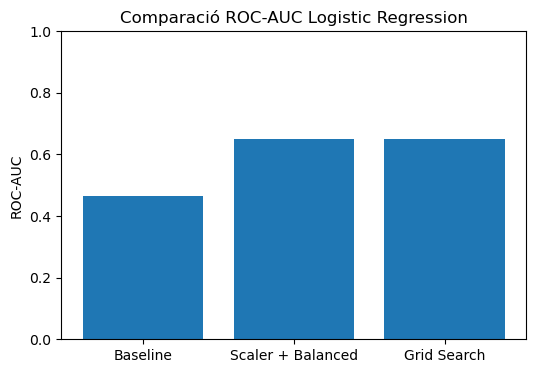

In [32]:
import matplotlib.pyplot as plt

models = ["Baseline", "Scaler + Balanced", "Grid Search"]
auc_scores = [0.465, 0.651, 0.651]

plt.figure(figsize=(6,4))
plt.bar(models, auc_scores)
plt.title("Comparació ROC-AUC Logistic Regression")
plt.ylabel("ROC-AUC")
plt.ylim(0,1)
plt.show()

- El primer model és completament inútil per detectar frau.

- L’escala i el balanceig són clau per a millorar el model.

- El Grid Search confirma la configuració òptima però no augmenta significativament les mètriques.

Els resultats mostren clarament que la regressió logística és molt sensible al preprocessament de les dades. Sense escalat ni balanceig, el model no és capaç de detectar frau. Amb aquestes millores, el rendiment augmenta considerablement. No obstant això, l’optimització d’hiperparàmetres no aporta millores addicionals, indicant que la limitació principal és la naturalesa lineal del model. Això suggereix la necessitat d’utilitzar models no lineals per capturar millor la complexitat del problema.

## Interpretar el model i veure quines variables són més rellevants

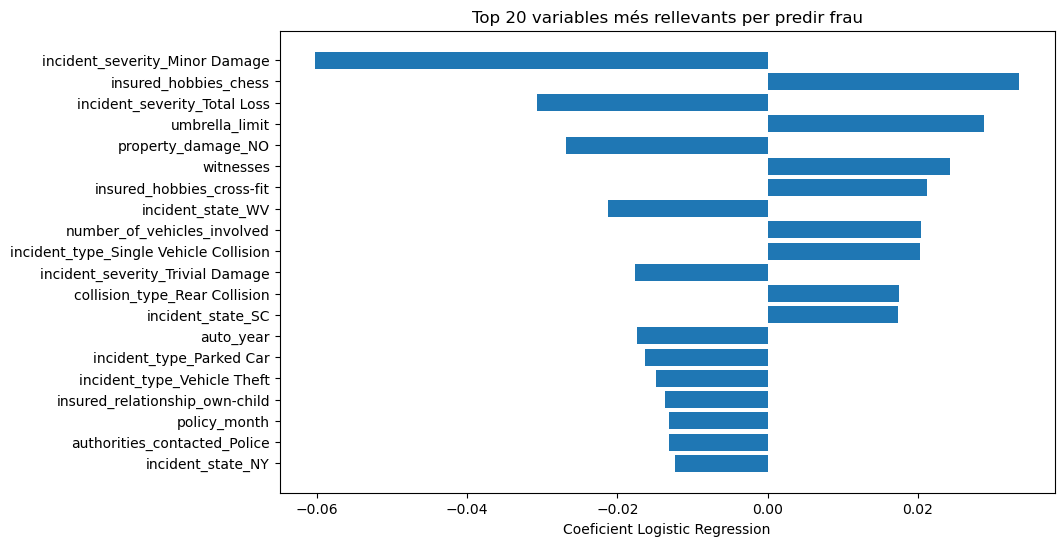

In [36]:
# Top 20 variables més rellevants 
coefs = best_model.coef_[0]        # coeficients del model final
features = X_train.columns

coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': coefs,
    'abs_coef': abs(coefs)
})

coef_df_sorted = coef_df.sort_values(by='abs_coef', ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(coef_df_sorted['feature'], coef_df_sorted['coefficient'])
plt.xlabel("Coeficient Logistic Regression")
plt.title("Top 20 variables més rellevants per predir frau")
plt.gca().invert_yaxis()
plt.show()

- Positius → contribueixen a predir fraud_binary = 1 (frau).
- Negatius → contribueixen a predir fraud_binary = 0 (no-frau).

Valor absolut gran → variable molt influent.

Signe → direcció de la influència

Les 20 variables amb més valor absolut dels coeficients indiquen quines features contribueixen més a predir frau.

Coeficients positius (a la dreta de 0) → augmenten la probabilitat de frau.
Coeficients negatius (a l’esquerra de 0) → disminueixen la probabilitat de frau.
2. Observacions destacades
- incident_severity_Minor Damage amb coeficient negatiu → incidents menors redueixen probabilitat que sigui frau.
- insured_hobbies_chess amb coeficient positiu → segons el model, tenir aquesta afició augmenta lleugerament la probabilitat de frau (pot ser un patró detectat per l’algorisme, no necessàriament causal).
- incident_severity_Total Loss amb coeficient negatiu → incidents amb pèrdua total redueixen probabilitat de frau segons el model (potser perquè són més visibles i difícils de falsificar).
- umbrella_limit positiu → a més límit de pòlissa, més probabilitat de frau.
- property_damage_NO positiu → si no hi ha danys a la propietat, més probabilitat de frau (té sentit: reclamacions sense dany poden ser més sospitoses).
witnesses positiu → a més testimonis, més probabilitat de frau segons el model, cosa que podria reflectir patrons de dades.
- Hobbies com cross-fit també apareixen, indicant que certes categories concretes de variables categòriques poden tenir impacte.
- Variables com incident_state_WV, incident_type_Single Vehicle Collision, collision_type_Rear Collision, auto_year, etc. apareixen com influents però amb coeficients menors.

**Interpretació general**
- Els coeficients no són molt grans → cap variable domina totalment el model, però hi ha certes categories que aporten informació significativa.
- Signe dels coeficients → ajuda a entendre direcció de la influència: negatiu → disminueix probabilitat de frau, positiu → augmenta.
- Podem utilitzar aquestes 20 variables com evidència de “caixa blanca” per explicar com el model pren decisions.

#### Gràfic de distribució de probabilitats

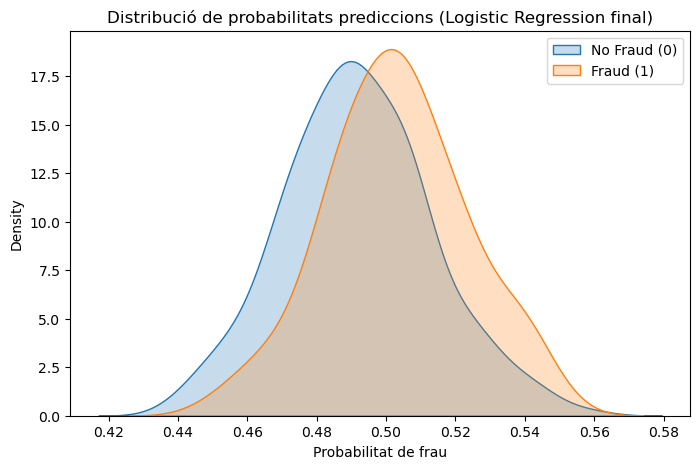

In [41]:
results_df = pd.DataFrame({
    'y_test': y_test,
    'y_pred_proba': y_pred_proba_best
})

plt.figure(figsize=(8,5))
sns.kdeplot(
    data=results_df[results_df['y_test'] == 0],
    x='y_pred_proba',
    label='No Fraud (0)',
    fill=True
)
sns.kdeplot(
    data=results_df[results_df['y_test'] == 1],
    x='y_pred_proba',
    label='Fraud (1)',
    fill=True
)

plt.title("Distribució de probabilitats prediccions (Logistic Regression final)")
plt.xlabel("Probabilitat de frau")
plt.legend()
plt.show()

Les dues corbes estan molt solapades cosa que indica que el model no separa bé les classes Dona probabilitats molt semblants tant a fraus reals com a no fraus. Això implica que li costa distingir patrons clars, detecta una mica de frau pero no el separa bé.

Per tant, podem dir que les relacions entre variables i frau no són lineals.

## 4. Model no lineal: Decision tree

In [44]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# Model
dt = DecisionTreeClassifier(
    max_depth=5, 
    class_weight="balanced",
    random_state=42
)

# Entrenar
dt.fit(X_train, y_train)

# Prediccions
y_pred_proba_dt = dt.predict_proba(X_test)[:, 1]

# ROC-AUC
roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt)
print("ROC-AUC Decision Tree:", roc_auc_dt)

# Classificació
y_pred_dt = (y_pred_proba_dt >= 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

ROC-AUC Decision Tree: 0.7867734991628798
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87       226
           1       0.59      0.80      0.68        74

    accuracy                           0.81       300
   macro avg       0.76      0.81      0.77       300
weighted avg       0.84      0.81      0.82       300

Confusion Matrix:
[[185  41]
 [ 15  59]]


Per tal de capturar possibles relacions no lineals entre les variables, s’ha entrenat un model de tipus Decision Tree. A diferència de la regressió logística, aquest model és capaç de modelar interaccions complexes entre variables sense necessitat de transformacions addicionals.

El model Decision Tree obté un ROC-AUC de 0.787, significativament superior al de la regressió logística (~0.65), indicant una millor capacitat de discriminació entre casos de frau i no frau.

Pel que fa a la detecció de frau (classe 1), el model aconsegueix:

- Recall = 0.80 → detecta el 80% dels fraus
- Precision = 0.59 → genera alguns falsos positius, però és acceptable en aquest context

En problemes de detecció de frau, és preferible maximitzar el recall, ja que és més crític detectar fraus reals que evitar falsos positius.

Classe no frau (0): El model també classifica bé els casos normals, mantenint un bon equilibri (Precision i recall elevats (>0.80))

La matriu de confusió mostra una millora clara respecte a la regressió logística:

- 59 fraus detectats correctament
- Només 15 fraus no detectats (reducció significativa dels falsos negatius)

En conjunt, el model presenta un bon equilibri entre detecció de frau i classificació de casos no fraudulents.

A continuació es comparen els resultats dels models de regressió logística i Decision Tree sobre el conjunt de test.

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
import pandas as pd

# 1. Crear dataframe de comparació de metrics
results = []

models = {
    "Logistic Regression": best_model,
    "Decision Tree": dt
}

for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:,1]
    y_pred_class = (y_pred_proba >= 0.5).astype(int)
    roc = roc_auc_score(y_test, y_pred_proba)
    report = classification_report(y_test, y_pred_class, output_dict=True)
    
    results.append({
        "Model": name,
        "Accuracy": report["accuracy"],
        "Precision_0": report["0"]["precision"],
        "Recall_0": report["0"]["recall"],
        "F1_0": report["0"]["f1-score"],
        "Precision_1": report["1"]["precision"],
        "Recall_1": report["1"]["recall"],
        "F1_1": report["1"]["f1-score"],
        "ROC-AUC": roc
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1,ROC-AUC
0,Logistic Regression,0.626667,0.816667,0.650442,0.724138,0.341667,0.554054,0.422680,0.651399
1,Decision Tree,0.813333,0.925000,0.818584,0.868545,0.590000,0.797297,0.678161,0.786773



Confusion Matrix Logistic Regression:
[[147  79]
 [ 33  41]]

Confusion Matrix Decision Tree:
[[185  41]
 [ 15  59]]


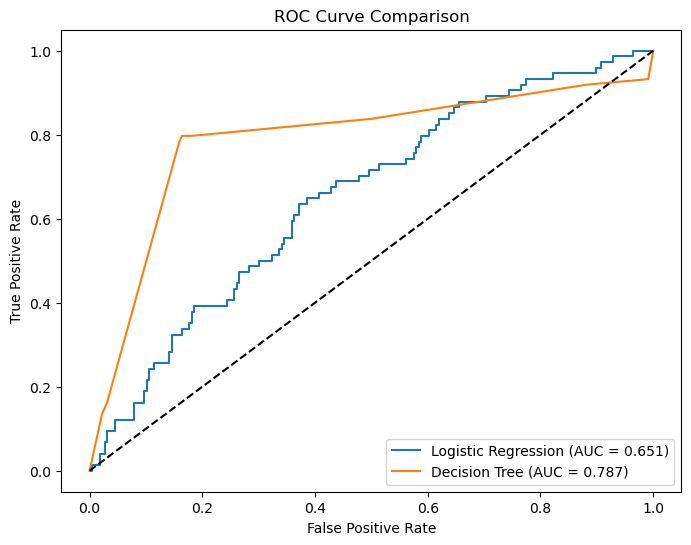

In [48]:
# 2. Matrius de confusió
for name, model in models.items():
    y_pred_class = (model.predict_proba(X_test)[:,1] >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred_class)
    print(f"\nConfusion Matrix {name}:\n{cm}")

# 3. ROC curves
plt.figure(figsize=(8,6))
for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.show()

Els resultats mostren clarament que el Decision Tree supera la regressió logística en totes les mètriques rellevants:

- Millor ROC-AUC (0.79 vs 0.65)
- Millor recall en la classe de frau (0.80 vs 0.55)
- Millor F1-score global

Això indica que el Decision Tree és capaç de capturar patrons que la regressió logística, com a model lineal, no pot representar.

A més, el model manté una bona interpretabilitat, ja que es poden analitzar les regles de decisió, fet especialment rellevant en entorns com el sector assegurador.

### Cross Validation

Per tal de validar la robustesa dels models i assegurar que els resultats no depenen d’una única partició train/test, s’ha aplicat validació creuada (5-fold cross-validation).

In [52]:
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": best_model,
    "Decision Tree": dt
}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='roc_auc'
    )
    
    print(f"{name} CV ROC-AUC: {scores}")
    print(f"Mitjana: {scores.mean():.3f}")
    print("-"*40)

Logistic Regression CV ROC-AUC: [0.50693674 0.60238624 0.47809524 0.49877551 0.57278912]
Mitjana: 0.532
----------------------------------------
Decision Tree CV ROC-AUC: [0.73903996 0.8318535  0.86190476 0.74380952 0.83469388]
Mitjana: 0.802
----------------------------------------


Els resultats de la validació creuada mostren que:

- La regressió logística presenta un rendiment baix i inestable (ROC-AUC mitjà ≈ 0.53)
- El Decision Tree manté un rendiment elevat i consistent (ROC-AUC mitjà ≈ 0.80)

Això confirma que el Decision Tree no només funciona millor en el conjunt de test, sinó que també generalitza millor a diferents particions de dades.

Per contra, la regressió logística mostra una capacitat limitada per capturar els patrons del problema, fins i tot amb preprocessament i optimització.

Després d'analitzar el rendiment de models baseline tant lineals com no lineals per a la detecció de frau, els resultats mostren que:

- La regressió logística és fortament dependent del preprocessament i presenta limitacions degudes a la seva naturalesa lineal.
- El Decision Tree millora significativament el rendiment, especialment en la detecció de frau.

La validació creuada confirma aquests resultats, mostrant que el model no lineal és més robust i generalitza millor.

Aquests resultats suggereixen que el problema presenta relacions no lineals entre variables, fet que justifica l’ús de models més avançats en la següent fase, com ara models de random forest o xarxes neuronals.
